In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn import svm

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix

In [5]:
#Import the Dataset
df= pd.read_csv("../dataset/English-OSINT.csv")
df=df.drop(columns=['latency','scan_duration'])
df.head()

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,1,0,82.165.229.59,1,3,996,"443, 8008, 80",NaN,1,"http, https",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",NaN,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,1,1,104.21.22.148,1,5,994,"80, 8008, 8080, 8443, 443",NaN,1,"http-proxy, http, https-alt, https",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.siliconvalley.com, www.ceert.org",1,0,"72.167.68.110, 192.0.66.2",1,"11, 3","996, 982","110, 21, 22, 993, 80, 995, 8008, 443, 8008, 80...",", 110.68.167.72.host.secureserver.net",1,"mysql, ssh, pop3, imaps, ftp, imap, http, http...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,1,0,128.240.208.85,1,3,996,"443, 8008, 80",apps-extweb-l.ncl.ac.uk,1,"http, https",0,0,0,0,Safe Email


In [6]:
int_keys = ["ip_found","host_found","interesting_url","asn_found","ip_found",
            "host_up","alternate_ip_count","common_web_ports_open","filtered_ports_count",
            "https_supported","open_ports_count"]
for itm in int_keys:
    df[itm].fillna(0,inplace = True) 

string_keys=["hostname","ip_address","services","open_ports","rdns_record"]
for itm in string_keys:
    df[itm].fillna('',inplace = True)

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_16280\1492188865.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[itm].fillna(0,inplace = True)
C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_16280\1492188865.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [7]:
df.isna().sum()

email_text               0
hostname                 0
host_up                  0
alternate_ip_count       0
ip_address               0
common_web_ports_open    0
open_ports_count         0
filtered_ports_count     0
open_ports               0
rdns_record              0
https_supported          0
services                 0
host_found               0
interesting_url          0
asn_found                0
ip_found                 0
email_type               0
dtype: int64

In [8]:
# Handle integer columns
int_keys = [
    "ip_found", "host_found", "interesting_url", "asn_found", "host_up",
    "alternate_ip_count", "common_web_ports_open", "filtered_ports_count",
    "https_supported", "open_ports_count"
]
for itm in int_keys:
    # Convert to numeric, coerce errors, and fill NaN with 0 before converting to int
    df[itm] = pd.to_numeric(df[itm], errors="coerce").fillna(0).astype("int")


In [9]:
df.shape

(1484, 17)

In [10]:
# Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        1232
Phishing Email     252
Name: count, dtype: int64


In [11]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [12]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((252, 17), (252, 17))

In [13]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Today's error(received multiple times) was:Jul...,"lists.sourceforge.net, thinkgeek.com",1,0,"216.105.38.7, 3.168.236.84",0,0,0,"443, 8008, 80",", server-3-168-236-84.ist50.r.cloudfront.net",0,"http, https",0,0,0,0,Safe Email
1,die offs in areas with better records parallel...,xent.com,1,0,69.55.232.243,1,4,0,"443, 22, 8008, 80",,1,"ssh, http, https",0,0,0,0,Safe Email
2,"On Thu, 1 Aug 2002 17:10:48 +0100, John Hinsle...",www.CounterMoon.com,0,0,15.197.148.33,0,0,0,"443, 8008, 80",a2aa9ff50de748dbe.awsglobalaccelerator.com,0,"http, https",0,0,0,0,Safe Email
3,Our preschoolers (2 and 4) use Winamp with a P...,www.teledyn.com,1,0,172.217.20.83,1,3,996,"443, 8008, 80",ams15s33-in-f19.1e100.net,1,"http, https",0,0,0,0,Safe Email
4,"is just an semi-educated guess - if I'm wrong,...",", thinkgeek.com",0,0,", 3.168.236.84",0,0,0,", 443, 8008, 80",", server-3-168-236-84.ist50.r.cloudfront.net",0,", http, https",0,0,0,0,Safe Email


In [14]:
# split the data into a metrix of features X and Dependent Variable y
X = Data["email_text"].values
y = Data["email_type"].values

In [ ]:
# #split the dataset
# x_train, x_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state=0)

In [ ]:
# cv = CountVectorizer() 
# x_train = cv.fit_transform(x_train)
# x_test = cv.transform(x_test)

In [ ]:
# #C, kernel and gamma are hyperparameters
# model = SVC(random_state = 0, C = 100, gamma = 0.1) 
# model.fit(x_train, y_train)

SVC(C=100, gamma=0.1, random_state=0)

In [ ]:
# y_pred = model.predict(x_test)

Accuracy: 0.94
Precision: 0.97
Recall: 0.71
F1 Score: 0.82
Confusion Matrix:
[[358   2]
 [ 25  61]]


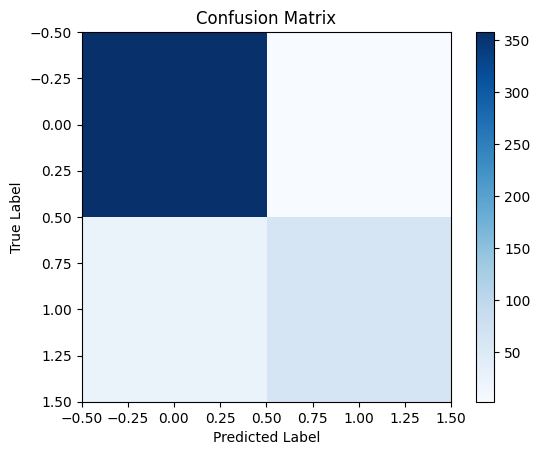

In [16]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Replace labels and convert to integer
df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# Define categorical and numerical features
categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
numerical_features = [
    'host_up', 'alternate_ip_count', 'common_web_ports_open',
    'open_ports_count', 'filtered_ports_count', 'https_supported',
    'host_found', 'interesting_url', 'asn_found', 'ip_found'
]

# Handle missing values
df[numerical_features] = df[numerical_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('unknown')

# Encode categorical features
onehot = OneHotEncoder(handle_unknown='ignore')
encoded_categorical = onehot.fit_transform(df[categorical_features])

# Scale numerical features
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features])

# Combine categorical and numerical features
X_additional = hstack([encoded_categorical, scaled_numerical])

# Convert email text feature using TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df['email_text'])

# Combine TF-IDF-transformed text and additional features
X_combined = hstack([X_text, X_additional])

# Define the target variable
Y = df['email_type']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=42)

# Define SVM model
svm_model = SVC(random_state = 0, C = 100, gamma = 0.1)   # Use a linear kernel for simplicity; adjust as needed

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix (Optional)
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [18]:
# Model Accuracy
# record accuracy in file
with open("osint_svm_accuracy.txt", "a") as file:
    file.write(f"\n Model Accuracy: {accuracy_score(y_test, y_pred):.2f}\n Precision: {precision_score(y_test, y_pred,pos_label=1):.2f}\n Recall: {recall_score(y_test, y_pred,pos_label=1):.2f}\n Confusion matrix:\n{confusion_matrix(y_test,y_pred)}")